In [218]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [219]:
data = pd.read_csv('Airbnb_Open_Data.csv', parse_dates=['last review'])

/tmp/ipykernel_5694/3090607538.py:1: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('Airbnb_Open_Data.csv', parse_dates=['last review'])


In [220]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102349 non-null  str           
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  str           
 4   host name                       102193 non-null  str           
 5   neighbourhood group             102570 non-null  str           
 6   neighbourhood                   102583 non-null  str           
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  str           
 10  country code                    102468 non-null  str           
 11

In [221]:
data.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [222]:
columns = data.columns.to_list()


=== MISSING VALUES ===
                                Missing_Count  Missing_Percentage
license                                102597           99.998051
house_rules                             52131           50.810437
last review                             15893           15.490404
reviews per month                       15879           15.476759
country                                   532            0.518524
availability 365                          448            0.436651
minimum nights                            409            0.398639
host name                                 406            0.395715
review rate number                        326            0.317742
calculated host listings count            319            0.310919
host_identity_verified                    289            0.281679
service fee                               273            0.266084
NAME                                      250            0.243667
price                                     247       

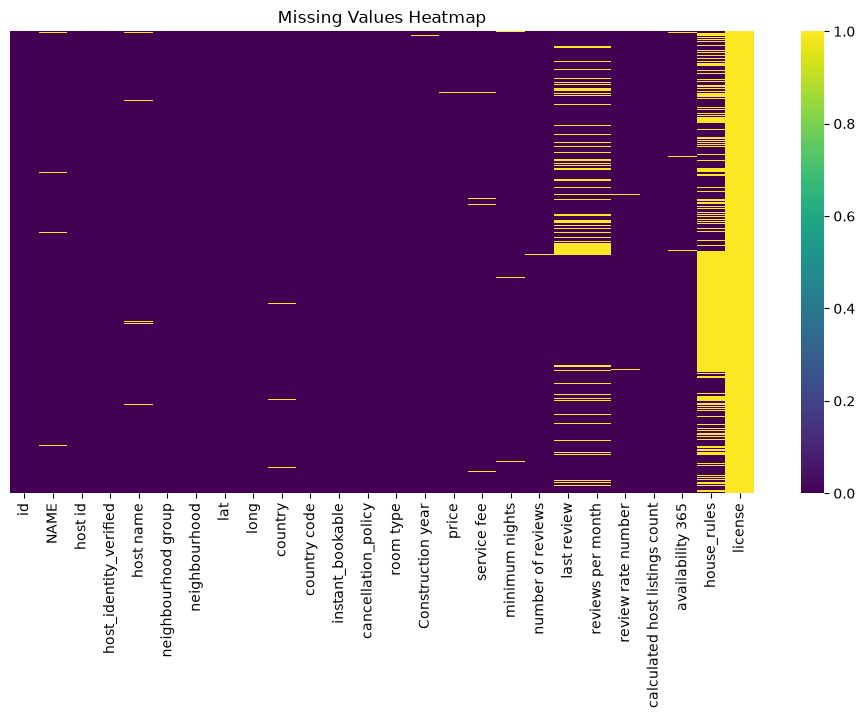

In [223]:
missing = data.isnull().sum()
missing_percent = (missing / len(data)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_percent
}).sort_values('Missing_Percentage', ascending=False)

print("\n=== MISSING VALUES ===")
print(missing_df[missing_df['Missing_Count'] > 0])

# Visualize missing data
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


# DATA CLEANING
1. deleting redundant columns
2. renaming the columns
3. dropping duplicates
4. removing the NAN values
5. cleaning individual columns
6. checking for more transformations


In [224]:
columns_to_keep = ['id', 'NAME', 'host id', 'host_identity_verified',
                   'neighbourhood group', 'neighbourhood', 'lat', 'long',
                   'country', 'country code', 'instant_bookable',
                   'cancellation_policy',
                   'room type',
                   'Construction year',
                   'price',
                   'service fee',
                   'minimum nights',
                   'number of reviews',
                   'last review', ]


# 1: deleting redundant columns

In [225]:

columns_to_drop = [col for col in columns if col not in columns_to_keep]
columns_to_drop

['host name',
 'reviews per month',
 'review rate number',
 'calculated host listings count',
 'availability 365',
 'house_rules',
 'license']

In [226]:
data.drop(columns=columns_to_drop, inplace=True)

# 2: renaming the columns

In [227]:
new_column_names = []
for col in data.columns:
    new_column_names.append(col.replace(' ', '_').lower())

new_column_names

['id',
 'name',
 'host_id',
 'host_identity_verified',
 'neighbourhood_group',
 'neighbourhood',
 'lat',
 'long',
 'country',
 'country_code',
 'instant_bookable',
 'cancellation_policy',
 'room_type',
 'construction_year',
 'price',
 'service_fee',
 'minimum_nights',
 'number_of_reviews',
 'last_review']

In [228]:
data.rename(columns=dict(zip(data.columns, new_column_names)), inplace=True)

# 3: dropping duplicates

In [229]:
data.duplicated().sum()

np.int64(541)

In [230]:
data[data.duplicated()]

,id,name,host_id,host_identity_verified,neighbourhood_group,neighbourhood,lat,long,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews,last_review
102058,35506831,Master Bedroom with private Bathroom & Balcony,55110690425,unconfirmed,Queens,Maspeth,40.74056,-73.90635,United States,US,True,strict,Private room,2016.0,$706,$141,1.0,1.0,2021-11-14
102059,35507383,Cozy 2 br in sunny Fort Greene apt,80193772189,verified,Brooklyn,Fort Greene,40.68701,-73.97555,United States,US,False,flexible,Private room,2020.0,$651,$130,3.0,38.0,2021-11-13
102060,35507935,Duplex w/ Terrace @ Box House Hotel,72991962259,verified,Brooklyn,Greenpoint,40.73756,-73.95350,United States,US,False,strict,Hotel room,2016.0,$907,$181,3.0,10.0,2021-11-13
102061,35508488,"Cozy, clean Greenpoint room with yard access",74975156081,verified,Brooklyn,Greenpoint,40.72516,-73.95004,United States,US,False,strict,Private room,2013.0,$589,$118,30.0,38.0,2021-11-13
102062,35509040,2BR XL Loft: Cleaning CDC guidelines implemented,85844415221,unconfirmed,Brooklyn,Greenpoint,40.72732,-73.94185,United States,US,False,flexible,Entire home/apt,2015.0,$356,$71,30.0,13.0,2021-11-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102594,6092437,Spare room in Williamsburg,12312296767,verified,Brooklyn,Williamsburg,40.70862,-73.94651,United States,US,False,flexible,Private room,2003.0,$844,$169,1.0,0.0,NaT
102595,6092990,Best Location near Columbia U,77864383453,unconfirmed,Manhattan,Morningside Heights,40.80460,-73.96545,United States,US,True,moderate,Private room,2016.0,$837,$167,1.0,1.0,2015-07-06
102596,6093542,"Comfy, bright room in Brooklyn",69050334417,unconfirmed,Brooklyn,Park Slope,40.67505,-73.98045,United States,US,True,moderate,Private room,2009.0,$988,$198,3.0,0.0,NaT
102597,6094094,Big Studio-One Stop from Midtown,11160591270,unconfirmed,Queens,Long Island City,40.74989,-73.93777,United States,US,True,strict,Entire home/apt,2015.0,$546,$109,2.0,5.0,2015-10-11


In [231]:
data.drop_duplicates(keep='first', inplace=True)

In [232]:
data.duplicated().sum()

np.int64(0)

# 4.Removing the NAN

In [233]:
data.isnull().sum()

id                            0
name                        250
host_id                       0
host_identity_verified      289
neighbourhood_group          29
neighbourhood                16
lat                           8
long                          8
country                     532
country_code                131
instant_bookable            105
cancellation_policy          76
room_type                     0
construction_year           214
price                       247
service_fee                 273
minimum_nights              400
number_of_reviews           183
last_review               15832
dtype: int64

In [234]:
data.drop(columns={'last_review'}, inplace=True)

In [235]:
data.dropna(inplace=True)

In [236]:
data.info()

<class 'pandas.DataFrame'>
Index: 99729 entries, 0 to 102044
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      99729 non-null  int64  
 1   name                    99729 non-null  str    
 2   host_id                 99729 non-null  int64  
 3   host_identity_verified  99729 non-null  str    
 4   neighbourhood_group     99729 non-null  str    
 5   neighbourhood           99729 non-null  str    
 6   lat                     99729 non-null  float64
 7   long                    99729 non-null  float64
 8   country                 99729 non-null  str    
 9   country_code            99729 non-null  str    
 10  instant_bookable        99729 non-null  object 
 11  cancellation_policy     99729 non-null  str    
 12  room_type               99729 non-null  str    
 13  construction_year       99729 non-null  float64
 14  price                   99729 non-null  str    
 15  

# 5. cleaning individual columns

In [237]:
data.head(10)

,id,name,host_id,host_identity_verified,neighbourhood_group,neighbourhood,lat,long,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0
1,1002102,Skylit Midtown Castle,52335172823,verified,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0
5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Manhattan,Murray Hill,40.74767,-73.97500,United States,US,True,flexible,Entire home/apt,2013.0,$577,$115,3.0,74.0
7,1005202,BlissArtsSpace!,90821839709,unconfirmed,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,US,False,moderate,Private room,2009.0,"$1,060",$212,45.0,49.0
8,1005754,Large Furnished Room Near B'way,79384379533,verified,Manhattan,Hell's Kitchen,40.76489,-73.98493,United States,US,True,strict,Private room,2005.0,"$1,018",$204,2.0,430.0
9,1006307,Cozy Clean Guest Room - Family Apt,75527839483,unconfirmed,Manhattan,Upper West Side,40.80178,-73.96723,United States,US,False,strict,Private room,2015.0,$291,$58,2.0,118.0
10,1006859,Cute & Cozy Lower East Side 1 bdrm,1280143094,verified,Manhattan,Chinatown,40.71344,-73.99037,United States,US,False,flexible,Entire home/apt,2004.0,$319,$64,1.0,160.0
11,1007411,Beautiful 1br on Upper West Side,18824631834,verified,Manhattan,Upper West Side,40.80316,-73.96545,United States,US,True,flexible,Entire home/apt,2008.0,$606,$121,5.0,53.0
12,1007964,Central Manhattan/near Broadway,88136055909,verified,Manhattan,Hell's Kitchen,40.76076,-73.98867,United States,US,False,strict,Private room,2008.0,$714,$143,2.0,188.0


In [238]:
data.info()

<class 'pandas.DataFrame'>
Index: 99729 entries, 0 to 102044
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      99729 non-null  int64  
 1   name                    99729 non-null  str    
 2   host_id                 99729 non-null  int64  
 3   host_identity_verified  99729 non-null  str    
 4   neighbourhood_group     99729 non-null  str    
 5   neighbourhood           99729 non-null  str    
 6   lat                     99729 non-null  float64
 7   long                    99729 non-null  float64
 8   country                 99729 non-null  str    
 9   country_code            99729 non-null  str    
 10  instant_bookable        99729 non-null  object 
 11  cancellation_policy     99729 non-null  str    
 12  room_type               99729 non-null  str    
 13  construction_year       99729 non-null  float64
 14  price                   99729 non-null  str    
 15  

In [239]:
data.nunique()

id                        99729
name                      60217
host_id                   99729
host_identity_verified        2
neighbourhood_group           6
neighbourhood               224
lat                       21850
long                      17649
country                       1
country_code                  1
instant_bookable              2
cancellation_policy           3
room_type                     4
construction_year            20
price                      1151
service_fee                 231
minimum_nights              146
number_of_reviews           473
dtype: int64

In [240]:
# cleaning host_identity_verified
data['host_identity_verified'] = data['host_identity_verified'].str.upper()
data['host_identity_verified'] = data['host_identity_verified'].astype('category')

In [241]:
# cleaning instant_bookable
data['instant_bookable'] = data['instant_bookable'].apply(lambda x: 1 if x == True else 0)

In [242]:
data.reset_index(inplace=True)
data.drop(columns=['index'], inplace=True)

In [244]:
data

,id,name,host_id,host_identity_verified,neighbourhood_group,neighbourhood,lat,long,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews
0,1001254,Clean & quiet apt home by the park,80014485718,UNCONFIRMED,Brooklyn,Kensington,40.64749,-73.97237,United States,US,0,strict,Private room,2020.0,$966,$193,10.0,9.0
1,1002102,Skylit Midtown Castle,52335172823,VERIFIED,Manhattan,Midtown,40.75362,-73.98377,United States,US,0,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0
2,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,VERIFIED,Manhattan,East Harlem,40.79851,-73.94399,United States,US,0,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0
3,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,VERIFIED,Manhattan,Murray Hill,40.74767,-73.97500,United States,US,1,flexible,Entire home/apt,2013.0,$577,$115,3.0,74.0
4,1005202,BlissArtsSpace!,90821839709,UNCONFIRMED,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,US,0,moderate,Private room,2009.0,"$1,060",$212,45.0,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99724,57358028,"Room in Queens, NY, near LGA.",56457739998,VERIFIED,Queens,East Elmhurst,40.76245,-73.87938,United States,US,1,strict,Private room,2022.0,$982,$196,1.0,239.0
99725,57358580,Cozy home away from home,60176837202,VERIFIED,Queens,Edgemere,40.59380,-73.77373,United States,US,1,moderate,Private room,2020.0,$946,$189,1.0,76.0
99726,57359133,Central Park Views - Private Room & Bathroom,68411243647,VERIFIED,Manhattan,Upper West Side,40.79712,-73.96117,United States,US,0,strict,Private room,2012.0,$706,$141,1.0,4.0
99727,57359685,Ultimate 50th Floor Downtown Penthouse - 4000...,95625271612,VERIFIED,Manhattan,SoHo,40.72318,-74.00223,United States,US,0,flexible,Entire home/apt,2020.0,"$1,043",$209,2.0,21.0


In [245]:
# cleaning service_fee and price
data[['service_fee', 'price']] = data[['service_fee', 'price']].apply(
    lambda x: x.str.replace('$', '').str.replace(',', '').astype(float))

In [250]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 99729 entries, 0 to 99728
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id                      99729 non-null  int64   
 1   name                    99729 non-null  str     
 2   host_id                 99729 non-null  int64   
 3   host_identity_verified  99729 non-null  category
 4   neighbourhood_group     99729 non-null  str     
 5   neighbourhood           99729 non-null  str     
 6   lat                     99729 non-null  float64 
 7   long                    99729 non-null  float64 
 8   country                 99729 non-null  str     
 9   country_code            99729 non-null  str     
 10  instant_bookable        99729 non-null  int64   
 11  cancellation_policy     99729 non-null  str     
 12  room_type               99729 non-null  str     
 13  construction_year       99729 non-null  float64 
 14  price                   99729 non

In [256]:
# save the cleaned data
data.to_csv('cleaned_airbnb_data.csv', index=False)